<div align="center">
  <img src="../assets/uepb_logo.png" width="150">
  <br>
  <strong>Universidade Estadual da Paraíba (UEPB)</strong><br>
  <strong>Professor(a):</strong> Thiciany Matsudo Iwano<br>
  <strong>Alunos:</strong> Tarcio Elyakin Agra Diniz & Djhonatah Wesley Cavalcanti Alves<br>
  <strong>Série:</strong> Sistemas Lineares: teoria, interpretação geométrica e aplicações com Python<br>
</div>

---

# [Tutorial 10] Aplicações Práticas

> **Pré-requisito:** [09] Transformações Lineares (`09_transformacoes_lineares.ipynb`)  
> **Próximo Passo:** [11] Conclusão e Exercícios (`11_conclusao_e_exercicios.ipynb`)

---

## Introdução

Neste tutorial, aplicaremos os conceitos de Álgebra Linear em problemas do mundo real. Demonstraremos como modelar o fluxo de veículos em malhas viárias utilizando sistemas lineares e como a conservação de fluxo em cruzamentos se traduz naturalmente em um sistema de equações.

Ao final deste tutorial, o estudante será capaz de:
1. Modelar problemas de rede utilizando a **Lei de Conservação de Fluxo**.
2. Formular o sistema $A\mathbf{x} = \mathbf{b}$ a partir de diagramas de fluxo.
3. Utilizar Python para encontrar soluções em redes complexas e interpretar o significado de variáveis livres.
4. Visualizar o fluxo em grafos utilizando a biblioteca **NetworkX**.

---

# 1. O Problema da Rede Viária

Imagine uma pequena seção de uma rede urbana com 4 cruzamentos (A, B, C e D) conectados por ruas de mão única. O fluxo de veículos que entra na rede deve ser igual ao fluxo que sai dela (Lei de Conservação de Fluxo) (BOLDRINI et al., 1980).

### Desenho da Rede (Esquema)
Representaremos a rede com os seguintes fluxos (veículos por hora - vph):

*   **Entradas:**
    *   No cruzamento A: 500 vph
    *   No cruzamento B: 300 vph
*   **Saídas:**
    *   No cruzamento C: 400 vph
    *   No cruzamento D: 400 vph
*   **Variáveis internas (fluxos entre cruzamentos):**
    *   $x_1$: de A para B
    *   $x_2$: de B para C
    *   $x_3$: de C para D
    *   $x_4$: de D para A
    *   $x_5$: de A para C (atalho)

---

# 2. Hipóteses e Variáveis do Modelo

### Hipóteses:
1.  **Conservação de Fluxo:** Em cada cruzamento, o fluxo total de entrada é igual ao fluxo total de saída (BOLDRINI et al., 1980).
2.  **Mão Única:** As direções dos fluxos são fixas conforme o esquema.
3.  **Estado Estacionário:** Os fluxos são constantes no tempo considerado.

### Variáveis:
*   $x_1, x_2, x_3, x_4, x_5$: Fluxos nas ruas internas (incógnitas).

---

# 3. Montando o Sistema Linear

Para cada cruzamento, escrevemos a equação de balanço: **Entrada = Saída** (BOLDRINI et al., 1980).

*   **Cruzamento A:** $500 + x_4 = x_1 + x_5$  $\implies x_1 - x_4 + x_5 = 500$
*   **Cruzamento B:** $300 + x_1 = x_2$ $\implies x_1 - x_2 = -300$
*   **Cruzamento C:** $x_2 + x_5 = x_3 + 400$ $\implies x_2 - x_3 + x_5 = 400$
*   **Cruzamento D:** $x_3 = x_4 + 400$ $\implies x_3 - x_4 = 400$

Note que o fluxo total de entrada ($500+300=800$) é igual ao de saída ($400+400=800$).

---

# 4. Forma Matricial $Ax = b$

O sistema acima pode ser escrito como (BOLDRINI et al., 1980):

$$
\begin{pmatrix}
1 & 0 & 0 & -1 & 1 \\
1 & -1 & 0 & 0 & 0 \\
0 & 1 & -1 & 0 & 1 \\
0 & 0 & 1 & -1 & 0
\end{pmatrix}
\begin{pmatrix}
x_1 \\ x_2 \\ x_3 \\ x_4 \\ x_5
\end{pmatrix}
=
\begin{pmatrix}
500 \\ -300 \\ 400 \\ 400
\end{pmatrix}
$$

Este é um sistema com 4 equações e 5 incógnitas, o que sugere que teremos pelo menos uma variável livre (SPI).

---

## 5. Resolução com SymPy

Vamos encontrar a solução geral desse sistema.


In [7]:
import sympy as sp

# Definindo as variáveis
x1, x2, x3, x4, x5 = sp.symbols('x1 x2 x3 x4 x5')

# Matriz A e vetor b
A = sp.Matrix([
    [1,  0,  0, -1,  1],
    [1, -1,  0,  0,  0],
    [0,  1, -1,  0,  1],
    [0,  0,  1, -1,  0]
])

b = sp.Matrix([500, -300, 400, 400])

# Matriz aumentada
aug = A.row_join(b)
display(aug)

# Forma Escalonada Reduzida (RREF)
rref_matrix, pivot_indices = aug.rref()
display(rref_matrix)

# Solução Geral
sol = sp.solve_linear_system(aug, x1, x2, x3, x4, x5)
display(sol)

Matrix([
[1,  0,  0, -1, 1,  500],
[1, -1,  0,  0, 0, -300],
[0,  1, -1,  0, 1,  400],
[0,  0,  1, -1, 0,  400]])

Matrix([
[1, 0, 0, -1, 1, 500],
[0, 1, 0, -1, 1, 800],
[0, 0, 1, -1, 0, 400],
[0, 0, 0,  0, 0,   0]])

{x1: x4 - x5 + 500, x2: x4 - x5 + 800, x3: x4 + 400}

---

# 6. Visualização da Rede e Fluxos

Para visualizar a rede, usaremos o `networkx` com a estética refinada do `seaborn`.


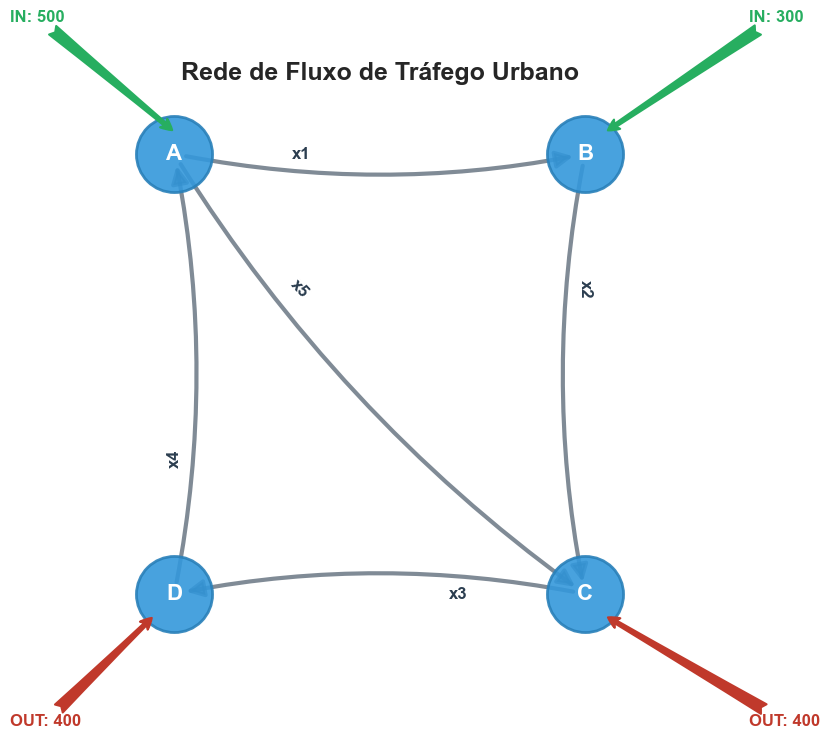

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo Seaborn
sns.set_theme(style="white", context="talk")

def plot_traffic_network(flow_values=None):
    G = nx.DiGraph()
    
    # Adicionando nós (Cruzamentos)
    nodes = ['A', 'B', 'C', 'D']
    G.add_nodes_from(nodes)
    
    # Adicionando arestas internas
    edges = [('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A'), ('A', 'C')]
    labels = ['x1', 'x2', 'x3', 'x4', 'x5']
    G.add_edges_from(edges)
    
    pos = {'A': (0, 1), 'B': (1, 1), 'C': (1, 0), 'D': (0, 0)}
    
    plt.figure(figsize=(10, 8))
    
    # Desenhando nós com estilo
    nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='#3498db', 
                           linewidths=2, edgecolors='#2980b9', alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=16, font_family='sans-serif', 
                            font_weight='bold', font_color='white')
    
    # Desenhando arestas com curvatura para melhor visualização
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=3, alpha=0.6, 
                           edge_color='#2c3e50', arrowsize=25, 
                           connectionstyle='arc3, rad = 0.1')
    
    # Labels das arestas
    if flow_values:
        edge_labels = {
            ('A', 'B'): f"x1={flow_values['x1']}",
            ('B', 'C'): f"x2={flow_values['x2']}",
            ('C', 'D'): f"x3={flow_values['x3']}",
            ('D', 'A'): f"x4={flow_values['x4']}",
            ('A', 'C'): f"x5={flow_values['x5']}"
        }
        label_color = '#e74c3c'
    else:
        edge_labels = {
            ('A', 'B'): 'x1',
            ('B', 'C'): 'x2',
            ('C', 'D'): 'x3',
            ('D', 'A'): 'x4',
            ('A', 'C'): 'x5'
        }
        label_color = '#2c3e50'

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                                 font_size=12, font_weight='bold', 
                                 font_color=label_color, label_pos=0.3)
    
    # Entradas e saídas externas com anotações bonitas
    ax = plt.gca()
    arrow_props = dict(arrowstyle="fancy", color='#27ae60', lw=1.5, mutation_scale=20)
    out_arrow_props = dict(arrowstyle="fancy", color='#c0392b', lw=1.5, mutation_scale=20)
    
    # Entradas (Verde)
    ax.annotate('IN: 500', xy=(0, 1.05), xytext=(-0.4, 1.3), 
                arrowprops=arrow_props, fontsize=12, weight='bold', color='#27ae60')
    ax.annotate('IN: 300', xy=(1.05, 1.05), xytext=(1.4, 1.3), 
                arrowprops=arrow_props, fontsize=12, weight='bold', color='#27ae60')
    
    # Saídas (Vermelho)
    ax.annotate('OUT: 400', xy=(1.05, -0.05), xytext=(1.4, -0.3), 
                arrowprops=out_arrow_props, fontsize=12, weight='bold', color='#c0392b')
    ax.annotate('OUT: 400', xy=(-0.05, -0.05), xytext=(-0.4, -0.3), 
                arrowprops=out_arrow_props, fontsize=12, weight='bold', color='#c0392b')
    
    plt.title("Rede de Fluxo de Tráfego Urbano", fontsize=18, fontweight='bold', pad=20)
    plt.axis('off')
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

plot_traffic_network()

---

## 7. Discussão 

Como o sistema é **SPI (Indeterminado)**, temos infinitas soluções dependendo do fluxo no "atalho" $x_5$. 

A partir da RREF, podemos expressar as outras variáveis em função de $x_5$ e $x_4$. No entanto, note que na nossa RREF obtivemos:
* $x_1 = x_4 - x_5 + 500$
* $x_2 = x_4 - x_5 + 800$
* $x_3 = x_4 + 400$

Como o fluxo não pode ser negativo ($x_i \ge 0$), isso impõe restrições aos valores possíveis.

### Exemplo de Solução Particular
Se decidirmos fechar o atalho ($x_5 = 0$) e minimizarmos o fluxo circular definindo $x_4 = 0$:


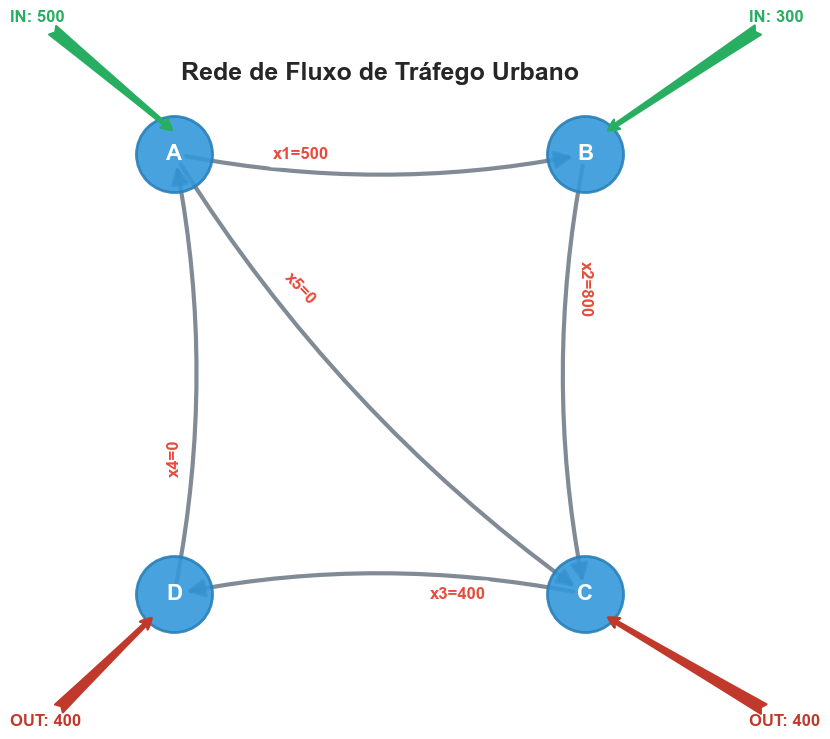

In [9]:
# Definindo x4 = 0 e x5 = 0 na solução geral
particular_sol = {
    'x1': 500,
    'x2': 800,
    'x3': 400,
    'x4': 0,
    'x5': 0
}

plot_traffic_network(particular_sol)

### Sensibilidade
Se o fluxo $x_5$ aumentar, os fluxos $x_1$ e $x_2$ diminuem na mesma proporção, o que faz sentido, já que $x_5$ retira veículos que passariam por A->B e B->C para irem direto para C.


---
## Próximo Passo

Você acaba de resolver um problema real de engenharia usando Álgebra Linear! Vimos como o escalonamento nos permite entender as capacidades de uma rede de tráfego.

No próximo tutorial, encerraremos nossa série com uma revisão dos conceitos fundamentais e exercícios de fixação.

👉 **[Ir para o Tutorial 11: Conclusão e Exercícios](./11_conclusao_e_exercicios.ipynb)**

---
> **"Linear algebra is the mathematics of the 21st century."** — *Stephen Boyd*
